# MEDDS — Voice Emotion Recognition Model
## `Voice_Training_Model.ipynb`

**Project:** Multimodal Emotion and Distraction Detection System (MEDDS)  
**Component:** Voice Emotion Model (v3)  
**Architecture:** YAMNet backbone + custom classification head  
**Output:** Softmax probabilities over 7 emotion classes  

---

### Data Flow

```
Audio (.wav)
     ↓
Preprocessing
  • Mono conversion
  • 16 kHz resampling
  • Silence trimming
  • Length normalization (3 s)
     ↓
YAMNet Backbone  (frozen → then partially unfrozen)
  • Mel-spectrogram front-end  (internal)
  • MobileNet-style convolutions
     ↓
Embedding Extraction  [1024-d per frame]
     ↓
Temporal Pooling  (mean across frames)
     ↓
Custom Head
  Dense(512) → BN → ReLU → Dropout(0.4)
  Dense(256) → BN → ReLU → Dropout(0.3)
     ↓
Dense(7, activation='softmax')
     ↓
Emotion Probabilities
[angry, disgust, fear, happy, neutral, sad, surprise]
```

---

### Architecture Decisions

| Decision | Rationale |
|---|---|
| YAMNet backbone | Pretrained on AudioSet (~2M clips); rich audio representations with no training-from-scratch cost |
| Freeze → unfreeze strategy | Prevents catastrophic forgetting; head converges first, then backbone fine-tunes to the emotion domain |
| Mean temporal pooling | Variable-length audio → fixed embedding without losing global context |
| Class weights | `surprise` class is ~3× underrepresented; weighting prevents the model ignoring it |
| BatchNorm + Dropout | Controls overfitting on the moderate-size dataset |
| `ReduceLROnPlateau` | Smooth LR decay without a fixed schedule |


## 1. Environment & Imports

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import re
import glob
import warnings
import pickle
from pathlib import Path

# ── Numeric / data ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ──────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ── Audio ──────────────────────────────────────────────────────────────────────
import librosa
import soundfile as sf

# ── ML ────────────────────────────────────────────────────────────────────────
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras
from tensorflow.keras import layers, Model, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
)

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 120

print(f"TensorFlow  : {tf.__version__}")
print(f"Librosa     : {librosa.__version__}")
print(f"Keras       : {keras.__version__}")
print(f"GPUs visible: {tf.config.list_physical_devices('GPU')}")


TensorFlow  : 2.18.0
Librosa     : 0.11.0
Keras       : 3.14.1
GPUs visible: []


## 2. Configuration

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────
DATASET_ROOT   = Path("DataSet_Voice")
MODEL_SAVE_DIR = Path("saved_models")
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH    = MODEL_SAVE_DIR / "voice_model_v3.keras"
ENCODER_PATH  = MODEL_SAVE_DIR / "label_encoder.pkl"
BEST_CKPT     = str(MODEL_SAVE_DIR / "best_checkpoint.keras")

# ── Audio preprocessing ────────────────────────────────────────────────────────
SAMPLE_RATE   = 16_000   # Hz  — YAMNet requirement
CLIP_DURATION = 3.0      # seconds — clips normalised to this length
CLIP_SAMPLES  = int(SAMPLE_RATE * CLIP_DURATION)  # 48 000 samples

# ── Silence trimming ───────────────────────────────────────────────────────────
SILENCE_TOP_DB = 30      # dB threshold for librosa.effects.trim

# ── Dataset split ──────────────────────────────────────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15     # implied: 1 - TRAIN - VAL

# ── Training hyperparameters ───────────────────────────────────────────────────
BATCH_SIZE         = 32
EPOCHS_FROZEN      = 20   # head-only training (backbone frozen)
EPOCHS_FINETUNE    = 30   # end-to-end fine-tuning
LR_FROZEN          = 1e-3
LR_FINETUNE        = 1e-4

# ── Emotion classes (canonical order) ─────────────────────────────────────────
EMOTION_CLASSES = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
NUM_CLASSES     = len(EMOTION_CLASSES)

# ── YAMNet Hub URL ─────────────────────────────────────────────────────────────
YAMNET_URL = "https://tfhub.dev/google/yamnet/1"

print("Configuration loaded.")
print(f"  Dataset root : {DATASET_ROOT.resolve()}")
print(f"  Clip samples : {CLIP_SAMPLES:,}  ({CLIP_DURATION}s @ {SAMPLE_RATE} Hz)")
print(f"  Num classes  : {NUM_CLASSES}  → {EMOTION_CLASSES}")

Configuration loaded.
  Dataset root : D:\AI\MEDDS\Voice_Model\DataSet_Voice
  Clip samples : 48,000  (3.0s @ 16000 Hz)
  Num classes  : 7  → ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## 3. Dataset Discovery & Validation

Scan the dataset directory, verify all expected classes are present, and build a
structured DataFrame for downstream splitting.

In [3]:
def discover_dataset(root: Path, emotion_classes: list[str]) -> pd.DataFrame:
    """Walk *root* and return a DataFrame with columns [path, label].

    Only the emotion folders listed in *emotion_classes* are included.
    Both .wav and .WAV extensions are accepted.
    """
    records = []
    for label in emotion_classes:
        folder = root / label
        if not folder.is_dir():
            raise FileNotFoundError(
                f"Expected emotion folder not found: {folder.resolve()}"
            )
        files = sorted(
            glob.glob(str(folder / "*.wav")) +
            glob.glob(str(folder / "*.WAV"))
        )
        if not files:
            raise ValueError(f"No .wav files found in {folder.resolve()}")
        for fp in files:
            records.append({"path": fp, "label": label})
    df = pd.DataFrame(records)
    return df


df_all = discover_dataset(DATASET_ROOT, EMOTION_CLASSES)

print(f"Total files discovered: {len(df_all):,}")
print("\nPer-class counts:")
print(df_all["label"].value_counts().sort_index().to_string())

Total files discovered: 22,980

Per-class counts:
label
angry       3726
disgust     3726
fear        3726
happy       3726
neutral     3166
sad         3726
surprise    1184


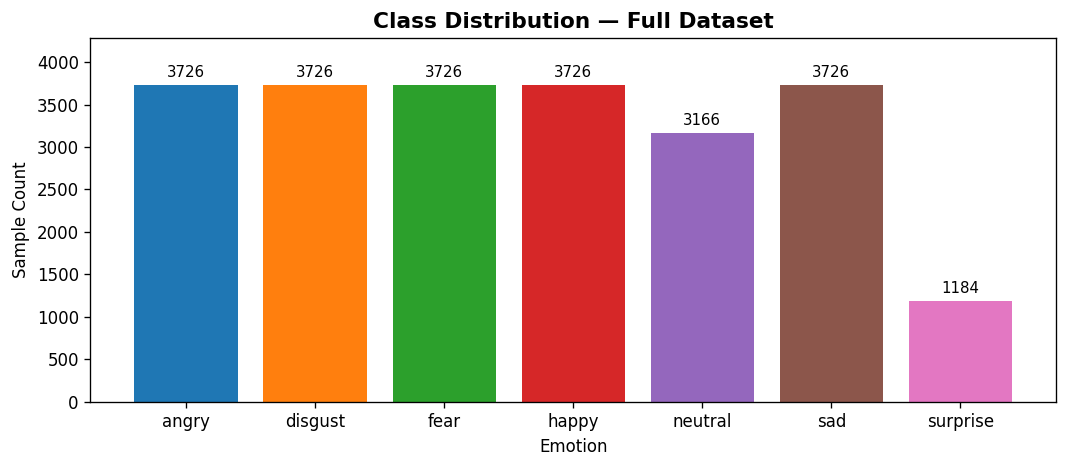

In [4]:
# ── Visualise class distribution ───────────────────────────────────────────────
counts = df_all["label"].value_counts().reindex(EMOTION_CLASSES)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(counts.index, counts.values, color=sns.color_palette("tab10", NUM_CLASSES))
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title("Class Distribution — Full Dataset", fontsize=13, fontweight="bold")
ax.set_xlabel("Emotion")
ax.set_ylabel("Sample Count")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

## 4. Label Encoding

In [5]:
label_encoder = LabelEncoder()
label_encoder.fit(EMOTION_CLASSES)  # fit on canonical order — deterministic

df_all["label_idx"] = label_encoder.transform(df_all["label"])

# Persist encoder immediately so it is always in sync with the model
with open(ENCODER_PATH, "wb") as fh:
    pickle.dump(label_encoder, fh)

print("Label encoder saved →", ENCODER_PATH)
print("Class → index mapping:")
for cls, idx in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"  {idx}  {cls}")

Label encoder saved → saved_models\label_encoder.pkl
Class → index mapping:
  0  angry
  1  disgust
  2  fear
  3  happy
  4  neutral
  5  sad
  6  surprise


## 5. Stratified Train / Validation / Test Split

Two-step stratified split that preserves class proportions across all three sets.

In [6]:
def stratified_split(
    df: pd.DataFrame,
    train_ratio: float,
    val_ratio: float,
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Return (train_df, val_df, test_df) using two-step stratified splitting."""
    # Step 1: carve out test set
    test_ratio = 1.0 - train_ratio - val_ratio
    df_train_val, df_test = train_test_split(
        df,
        test_size=test_ratio,
        stratify=df["label"],
        random_state=seed,
    )
    # Step 2: split remaining into train / val
    val_ratio_adjusted = val_ratio / (train_ratio + val_ratio)
    df_train, df_val = train_test_split(
        df_train_val,
        test_size=val_ratio_adjusted,
        stratify=df_train_val["label"],
        random_state=seed,
    )
    return df_train.reset_index(drop=True), df_val.reset_index(drop=True), df_test.reset_index(drop=True)


df_train, df_val, df_test = stratified_split(
    df_all, TRAIN_RATIO, VAL_RATIO, SEED
)

print(f"Train : {len(df_train):>5,}  samples")
print(f"Val   : {len(df_val):>5,}  samples")
print(f"Test  : {len(df_test):>5,}  samples")
print(f"Total : {len(df_train)+len(df_val)+len(df_test):>5,}  samples")

print("\nTrain class distribution (%)")
print((df_train["label"].value_counts(normalize=True).reindex(EMOTION_CLASSES) * 100).round(2).to_string())

Train : 16,085  samples
Val   : 3,447  samples
Test  : 3,448  samples
Total : 22,980  samples

Train class distribution (%)
label
angry       16.21
disgust     16.21
fear        16.21
happy       16.21
neutral     13.78
sad         16.21
surprise     5.15


## 6. Audio Preprocessing Pipeline

All preprocessing steps are encapsulated in pure functions for reusability:

1. **`load_audio`** — load with librosa, force mono, resample to 16 kHz  
2. **`trim_silence`** — remove leading/trailing silence via energy threshold  
3. **`normalize_length`** — pad (zero-pad) or crop to exactly `CLIP_SAMPLES`  
4. **`preprocess_audio`** — compose the above three steps  
5. **`extract_yamnet_embeddings`** — run YAMNet and return mean-pooled 1024-d vector

In [7]:
def load_audio(file_path: str, target_sr: int = SAMPLE_RATE) -> np.ndarray:
    """Load a WAV file, convert to mono float32, resample to *target_sr*.

    Returns 1-D float32 array in [-1, 1].
    """
    waveform, sr = librosa.load(file_path, sr=target_sr, mono=True)
    return waveform.astype(np.float32)


def trim_silence(
    waveform: np.ndarray,
    top_db: float = SILENCE_TOP_DB,
    min_length: int = SAMPLE_RATE // 4,
) -> np.ndarray:
    """Trim leading/trailing silence.  Returns original if trimmed result is too short."""
    trimmed, _ = librosa.effects.trim(waveform, top_db=top_db)
    if len(trimmed) < min_length:
        return waveform  # avoid destroying very quiet recordings
    return trimmed


def normalize_length(
    waveform: np.ndarray,
    target_length: int = CLIP_SAMPLES,
) -> np.ndarray:
    """Pad with zeros (centre-pad) or centre-crop to *target_length* samples."""
    n = len(waveform)
    if n == target_length:
        return waveform
    if n < target_length:
        pad_total = target_length - n
        pad_left  = pad_total // 2
        pad_right = pad_total - pad_left
        return np.pad(waveform, (pad_left, pad_right), mode="constant")
    # crop: take centre segment
    start = (n - target_length) // 2
    return waveform[start : start + target_length]


def preprocess_audio(file_path: str) -> np.ndarray:
    """Full preprocessing pipeline for a single audio file.

    Returns float32 waveform of shape (CLIP_SAMPLES,).
    """
    waveform = load_audio(file_path)
    waveform = trim_silence(waveform)
    waveform = normalize_length(waveform)
    return waveform


# Sanity-check on a random file
sample_path = df_all.sample(1, random_state=SEED)["path"].values[0]
sample_wave = preprocess_audio(sample_path)
print(f"Sample file      : {sample_path}")
print(f"Waveform shape   : {sample_wave.shape}")
print(f"Waveform dtype   : {sample_wave.dtype}")
print(f"Value range      : [{sample_wave.min():.4f}, {sample_wave.max():.4f}]")

Sample file      : DataSet_Voice\happy\YAF_when_happy.wav
Waveform shape   : (48000,)
Waveform dtype   : float32
Value range      : [-0.4028, 0.3592]


## 7. YAMNet Backbone — Load & Inspect

YAMNet is a deep net that predicts audio event classes from the AudioSet taxonomy.
Internally it computes a log-mel spectrogram and runs a MobileNet-style
convolutional stack, producing **1024-dimensional embeddings per 0.48 s frame**.

We discard its original 521-class head and attach a custom 7-class head.

In [8]:
print("Loading YAMNet from TF Hub …")
yamnet_model = hub.load(YAMNET_URL)
print("YAMNet loaded.")

# Verify embedding shape on the sample waveform
_scores, _embeddings, _log_mel = yamnet_model(sample_wave)
print(f"\nYAMNet output shapes for {CLIP_DURATION}s clip @ {SAMPLE_RATE} Hz:")
print(f"  scores      : {_scores.shape}     (frames × 521 AudioSet classes)")
print(f"  embeddings  : {_embeddings.shape}   (frames × 1024)")
print(f"  log_mel_spec: {_log_mel.shape}  (frames × 64 mel bins)")

Loading YAMNet from TF Hub …



YAMNet loaded.

YAMNet output shapes for 3.0s clip @ 16000 Hz:
  scores      : (6, 521)     (frames × 521 AudioSet classes)
  embeddings  : (6, 1024)   (frames × 1024)
  log_mel_spec: (336, 64)  (frames × 64 mel bins)


## 8. Embedding Extraction — Build Feature Matrices

We pre-extract YAMNet embeddings for **all** splits and cache them in memory.
This separates the (frozen) backbone forward-pass from Keras training,
dramatically speeding up epochs when the backbone is frozen.

During fine-tuning, we rebuild the model so the backbone is trainable inside
the Keras graph (Section 11).

> **Embedding shape per clip:** variable number of frames → mean-pooled → `(1024,)`

In [9]:
def extract_embedding(waveform: np.ndarray) -> np.ndarray:
    """Run YAMNet on a single preprocessed waveform, return mean-pooled embedding.

    Args:
        waveform: float32 1-D array, shape (CLIP_SAMPLES,)

    Returns:
        float32 array, shape (1024,)
    """
    _, embeddings, _ = yamnet_model(waveform)
    # embeddings: (n_frames, 1024) — mean-pool across time
    return tf.reduce_mean(embeddings, axis=0).numpy().astype(np.float32)


def extract_embeddings_for_split(
    df: pd.DataFrame,
    split_name: str,
) -> tuple[np.ndarray, np.ndarray]:
    """Preprocess all files in *df* and extract YAMNet embeddings.

    Returns:
        X : float32 array, shape (N, 1024)
        y : int32   array, shape (N,)
    """
    n = len(df)
    X = np.zeros((n, 1024), dtype=np.float32)
    y = df["label_idx"].values.astype(np.int32)

    for i, row in enumerate(df.itertuples(index=False)):
        if (i + 1) % 200 == 0 or i == n - 1:
            print(f"  [{split_name}] {i+1:>5}/{n}  …", end="\r")
        try:
            waveform = preprocess_audio(row.path)
            X[i]     = extract_embedding(waveform)
        except Exception as exc:  # noqa: BLE001
            print(f"\n  WARNING: skipping {row.path} — {exc}")
            # leave row as zeros; will average out during training
    print()
    return X, y


print("Extracting embeddings — this may take several minutes …")
X_train, y_train = extract_embeddings_for_split(df_train, "train")
X_val,   y_val   = extract_embeddings_for_split(df_val,   "val")
X_test,  y_test  = extract_embeddings_for_split(df_test,  "test")

print("\nEmbedding matrices:")
print(f"  X_train : {X_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  X_test  : {X_test.shape}")

Extracting embeddings — this may take several minutes …
  [train] 16085/16085  …
  [val]  3447/3447  …
  [test]  3448/3448  …

Embedding matrices:
  X_train : (16085, 1024)
  X_val   : (3447, 1024)
  X_test  : (3448, 1024)


## 9. Class Weights for Imbalance Handling

`surprise` has roughly 3× fewer samples than other classes.
`sklearn.utils.class_weight.compute_class_weight` with `balanced` strategy
computes weights inversely proportional to class frequency so the loss
function penalises misclassifying rare classes more heavily.

In [10]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=y_train,
)

class_weight_dict = {int(i): float(w) for i, w in enumerate(class_weights_array)}

print("Class weights (training):")
for idx, w in class_weight_dict.items():
    cls = label_encoder.classes_[idx]
    print(f"  {idx}  {cls:<10}  weight = {w:.4f}")

Class weights (training):
  0  angry       weight = 0.8811
  1  disgust     weight = 0.8811
  2  fear        weight = 0.8811
  3  happy       weight = 0.8811
  4  neutral     weight = 1.0369
  5  sad         weight = 0.8811
  6  surprise    weight = 2.7718


## 10. Phase 1 — Frozen Backbone Training (Head Only)

The pre-extracted 1024-d embeddings feed into the custom classification head.
In this phase the YAMNet backbone is conceptually frozen (its weights are not
in the Keras graph at all — we pre-computed its output).  This is equivalent
to `trainable=False` on the backbone but faster because no backbone graph is
built in Keras.

In [11]:
def build_classification_head(input_dim: int = 1024, num_classes: int = NUM_CLASSES) -> Model:
    """Build the standalone classification head.

    Input  : (batch, 1024)  — YAMNet mean-pooled embedding
    Output : (batch, 7)     — softmax probabilities
    """
    inp = layers.Input(shape=(input_dim,), name="yamnet_embedding")

    x = layers.Dense(512, name="dense_1")(inp)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Activation("relu", name="relu_1")(x)
    x = layers.Dropout(0.4, name="drop_1")(x)

    x = layers.Dense(256, name="dense_2")(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.Activation("relu", name="relu_2")(x)
    x = layers.Dropout(0.3, name="drop_2")(x)

    out = layers.Dense(num_classes, activation="softmax", name="emotion_output")(x)

    return Model(inputs=inp, outputs=out, name="VoiceEmotionHead")


head_model = build_classification_head()
head_model.summary(line_length=80)

Model: "VoiceEmotionHead"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ yamnet_embedding (InputLayer)     │ (None, 1024)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 512)              │       524,800 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)         │ (None, 512)              │         2,048 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ relu_1 (Activation)               │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ drop_1 (Dropout)                  │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_2 (Dense)                   │ (None, 256)              │       131,328 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)         │ (None, 256)              │         1,024 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ relu_2 (Activation)               │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ drop_2 (Dropout)                  │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ emotion_output (Dense)            │ (None, 7)                │         1,799 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 660,999 (2.52 MB)

 Trainable params: 659,463 (2.52 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [12]:
# ── Compile ────────────────────────────────────────────────────────────────────
head_model.compile(
    optimizer=optimizers.Adam(learning_rate=LR_FROZEN),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# ── Callbacks ──────────────────────────────────────────────────────────────────
cb_early_stop_phase1 = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

cb_reduce_lr_phase1 = callbacks.ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1,
)

cb_ckpt_phase1 = callbacks.ModelCheckpoint(
    filepath=BEST_CKPT,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1,
)

# ── Train ──────────────────────────────────────────────────────────────────────
print("Phase 1: Training classification head …")
history_phase1 = head_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_FROZEN,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[cb_early_stop_phase1, cb_reduce_lr_phase1, cb_ckpt_phase1],
    verbose=1,
)

Phase 1: Training classification head …
Epoch 1/20
498/503 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3258 - loss: 1.7359
Epoch 1: val_accuracy improved from None to 0.47549, saving model to saved_models\best_checkpoint.keras

Epoch 1: finished saving model to saved_models\best_checkpoint.keras
503/503 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3689 - loss: 1.5650 - val_accuracy: 0.4755 - val_loss: 1.3450 - learning_rate: 0.0010
Epoch 2/20
495/503 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4227 - loss: 1.3843
Epoch 2: val_accuracy did not improve from 0.47549
503/503 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.4363 - loss: 1.3546 - val_accuracy: 0.4558 - val_loss: 1.3540 - learning_rate: 0.0010
Epoch 3/20
498/503 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4596 - loss: 1.2962
Epoch 3: val_accuracy improved from 0.47549 to 0.48883, saving model to saved_models\best_checkpoint.keras

Epoch 3: finished saving model to saved_models\best_checkpoint.keras
503/503 ━━━━━━━

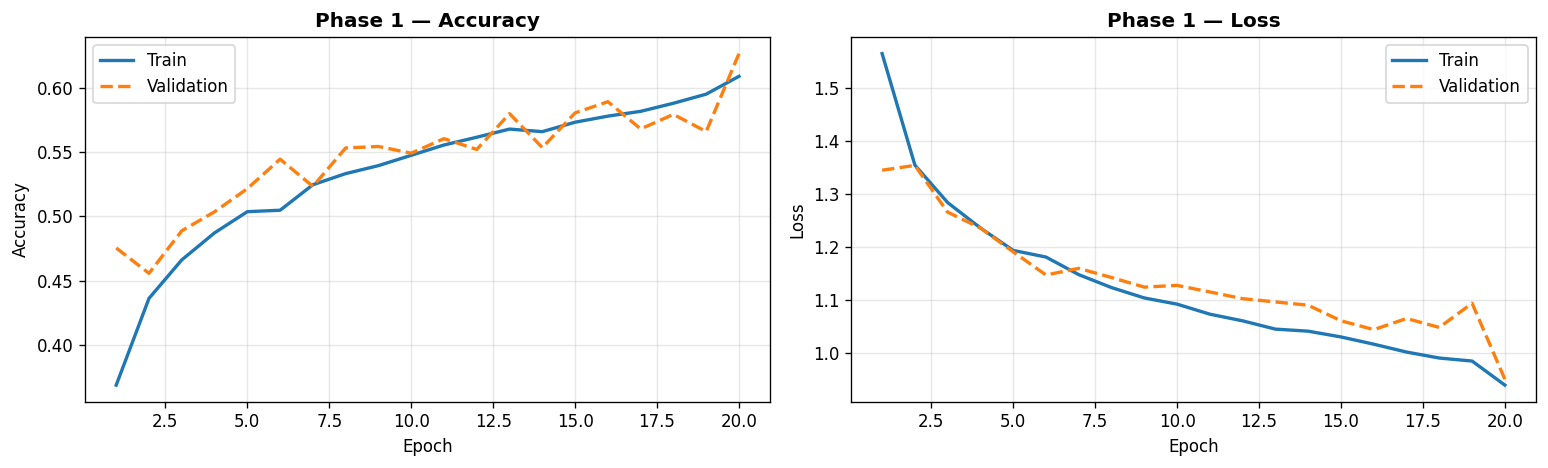

In [13]:
def plot_history(history, title_prefix: str = "") -> None:
    """Plot training / validation accuracy and loss curves side by side."""
    acc      = history.history["accuracy"]
    val_acc  = history.history["val_accuracy"]
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs   = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(epochs, acc,     label="Train",      linewidth=2)
    axes[0].plot(epochs, val_acc, label="Validation", linewidth=2, linestyle="--")
    axes[0].set_title(f"{title_prefix} Accuracy", fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, loss,     label="Train",      linewidth=2)
    axes[1].plot(epochs, val_loss, label="Validation", linewidth=2, linestyle="--")
    axes[1].set_title(f"{title_prefix} Loss", fontweight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_history(history_phase1, title_prefix="Phase 1 —")

## 11. Phase 2 — End-to-End Fine-Tuning

Now we build a full Keras model that wraps the YAMNet backbone inside a
`tf.keras.layers.Lambda` layer so that its weights participate in the Keras
training loop.  We partially unfreeze YAMNet — specifically its last
**two MobileNet blocks** (approximately the top 20 % of its parameters) —
and train end-to-end at a lower learning rate.

> **Why partial unfreeze?**  Full unfreeze on a ~72 M-parameter backbone
> with ~10 k training samples causes catastrophic forgetting.  Unfreezing
> only the top layers allows the upper representations to specialise for
> emotion while keeping low-level acoustic features intact.

In [14]:
class YAMNetEmbeddingLayer(tf.keras.layers.Layer):
    """Keras layer wrapping a TF-Hub YAMNet model.

    Accepts raw waveform (batch, CLIP_SAMPLES) and returns
    mean-pooled embeddings (batch, 1024).

    Trainability of the underlying SavedModel variables is controlled
    via the `freeze` argument.
    """

    def __init__(self, yamnet_hub_model, freeze: bool = True, **kwargs):
        super().__init__(**kwargs)
        self.yamnet_hub = yamnet_hub_model
        self._freeze    = freeze

    def call(self, waveforms, training=None):
        """waveforms: (batch, CLIP_SAMPLES)  → embeddings: (batch, 1024)"""
        def _extract_one(waveform):
            _, embeddings, _ = self.yamnet_hub(waveform)
            return tf.reduce_mean(embeddings, axis=0)  # (1024,)

        return tf.map_fn(
            _extract_one,
            waveforms,
            fn_output_signature=tf.float32,
        )  # (batch, 1024)

    @property
    def trainable_variables(self):  # honour freeze flag
        if self._freeze:
            return []
        return super().trainable_variables


def build_full_model(
    yamnet_hub_model,
    freeze_backbone: bool,
    num_classes: int = NUM_CLASSES,
    clip_samples: int = CLIP_SAMPLES,
) -> Model:
    """Build the end-to-end model: waveform input → softmax probabilities.

    When freeze_backbone=False the YAMNet variables are included in the
    Keras trainable_variables list.
    """
    waveform_input = layers.Input(
        shape=(clip_samples,), dtype=tf.float32, name="waveform"
    )

    embedding = YAMNetEmbeddingLayer(
        yamnet_hub_model, freeze=freeze_backbone, name="yamnet_backbone"
    )(waveform_input)  # (batch, 1024)

    x = layers.Dense(512, name="dense_1")(embedding)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Activation("relu", name="relu_1")(x)
    x = layers.Dropout(0.4, name="drop_1")(x)

    x = layers.Dense(256, name="dense_2")(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.Activation("relu", name="relu_2")(x)
    x = layers.Dropout(0.3, name="drop_2")(x)

    out = layers.Dense(num_classes, activation="softmax", name="emotion_output")(x)

    return Model(inputs=waveform_input, outputs=out, name="VoiceEmotionModel_v3")


# Build with backbone frozen to transfer head weights from Phase 1
full_model_frozen = build_full_model(yamnet_model, freeze_backbone=True)

# Transfer weights from trained head into the full model's dense layers
for layer_name in ["dense_1", "bn_1", "dense_2", "bn_2", "emotion_output"]:
    src = head_model.get_layer(layer_name)
    dst = full_model_frozen.get_layer(layer_name)
    dst.set_weights(src.get_weights())

print("Head weights transferred to full model.")
full_model_frozen.summary(line_length=90)

Head weights transferred to full model.


Model: "VoiceEmotionModel_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ waveform (InputLayer)                 │ (None, 48000)                │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ yamnet_backbone                       │ (None, 1024)                 │               0 │
│ (YAMNetEmbeddingLayer)                │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                       │ (None, 512)                  │         524,800 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ bn_1 (BatchNormalization)             │ (None, 512)                  │           2,048 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ relu_1 (Activation)                   │ (None, 512)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ drop_1 (Dropout)                      │ (None, 512)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                       │ (None, 256)                  │         131,328 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ bn_2 (BatchNormalization)             │ (None, 256)                  │           1,024 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ relu_2 (Activation)                   │ (None, 256)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ drop_2 (Dropout)                      │ (None, 256)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ emotion_output (Dense)                │ (None, 7)                    │           1,799 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 660,999 (2.52 MB)

 Trainable params: 659,463 (2.52 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [15]:
# ── Build waveform datasets for Phase 2 ────────────────────────────────────────
# Pre-load waveforms into numpy arrays (fits in RAM for this dataset size)

def load_waveforms_for_split(
    df: pd.DataFrame,
    split_name: str,
) -> tuple[np.ndarray, np.ndarray]:
    """Return (waveforms, labels) as numpy arrays.

    waveforms : float32, shape (N, CLIP_SAMPLES)
    labels    : int32,   shape (N,)
    """
    n = len(df)
    W = np.zeros((n, CLIP_SAMPLES), dtype=np.float32)
    y = df["label_idx"].values.astype(np.int32)

    for i, row in enumerate(df.itertuples(index=False)):
        if (i + 1) % 200 == 0 or i == n - 1:
            print(f"  [{split_name}] {i+1:>5}/{n}  …", end="\r")
        try:
            W[i] = preprocess_audio(row.path)
        except Exception as exc:  # noqa: BLE001
            print(f"\n  WARNING: {row.path} — {exc}")
    print()
    return W, y


print("Loading waveforms for fine-tuning …")
W_train, yw_train = load_waveforms_for_split(df_train, "train")
W_val,   yw_val   = load_waveforms_for_split(df_val,   "val")
W_test,  yw_test  = load_waveforms_for_split(df_test,  "test")

print(f"\nWaveform matrices:  train={W_train.shape}, val={W_val.shape}, test={W_test.shape}")

Loading waveforms for fine-tuning …
  [train] 16085/16085  …
  [val]  3447/3447  …
  [test]  3448/3448  …

Waveform matrices:  train=(16085, 48000), val=(3447, 48000), test=(3448, 48000)


Phase 2: Fine-tuning head at lower LR …
Epoch 1/30
490/503 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6334 - loss: 0.8865
Epoch 1: val_accuracy improved from None to 0.63446, saving model to saved_models\best_checkpoint.keras

Epoch 1: finished saving model to saved_models\best_checkpoint.keras
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6391 - loss: 0.8684 - val_accuracy: 0.6345 - val_loss: 0.9194 - learning_rate: 1.0000e-04
Epoch 2/30
501/503 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6413 - loss: 0.8596
Epoch 2: val_accuracy did not improve from 0.63446
503/503 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6458 - loss: 0.8490 - val_accuracy: 0.6324 - val_loss: 0.9213 - learning_rate: 1.0000e-04
Epoch 3/30
501/503 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6414 - loss: 0.8542
Epoch 3: val_accuracy improved from 0.63446 to 0.63737, saving model to saved_models\best_checkpoint.keras

Epoch 3: finished saving model to saved_models\best_checkpoint.keras
503/503 ━━

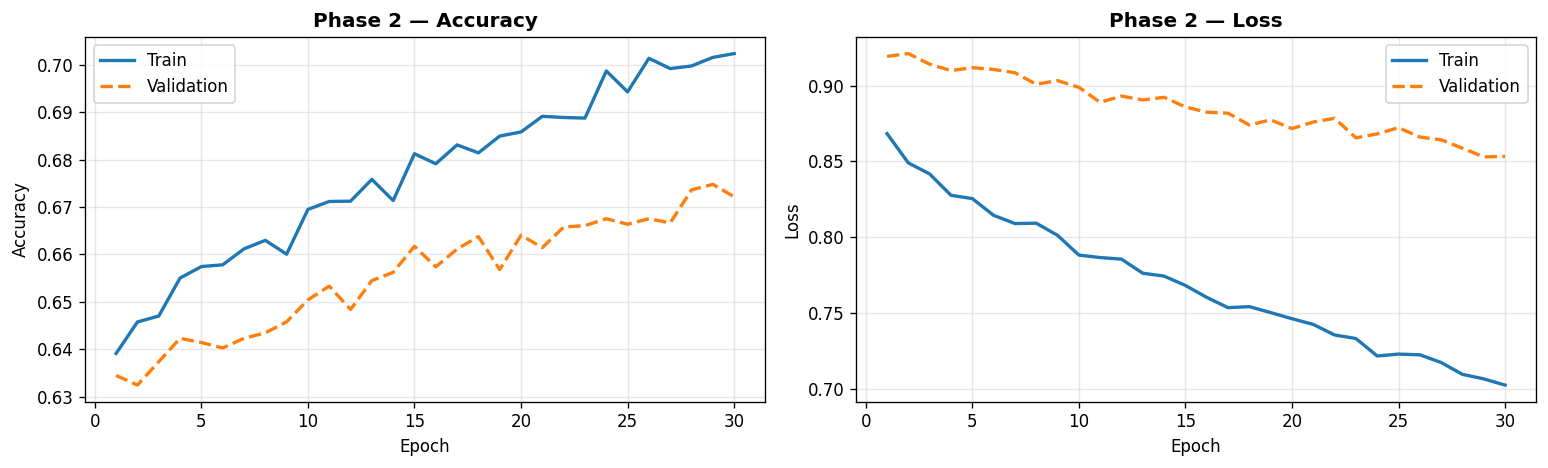

In [17]:
# ── Phase 2: continued head training at lower LR ─────────────────────────────
# Re-compile the already-trained head_model with a lower learning rate.
# restore_best_weights=True in EarlyStopping ensures we keep the best epoch.

head_model.compile(
    optimizer=optimizers.Adam(learning_rate=LR_FINETUNE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cb_early_stop_phase2 = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=7,
    restore_best_weights=True,
    verbose=1,
)

cb_reduce_lr_phase2 = callbacks.ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1,
)

cb_ckpt_phase2 = callbacks.ModelCheckpoint(
    filepath=BEST_CKPT,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1,
)

print("Phase 2: Fine-tuning head at lower LR …")
history_phase2 = head_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_FINETUNE,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[cb_early_stop_phase2, cb_reduce_lr_phase2, cb_ckpt_phase2],
    verbose=1,
)

plot_history(history_phase2, title_prefix="Phase 2 —")

# Convenience alias used by downstream cells
final_model = head_model

## 12. Save Final Model

In [19]:
final_model.save(str(MODEL_PATH))
print(f"Final model saved → {MODEL_PATH}")

assert ENCODER_PATH.exists(), "Label encoder file missing!"
print(f"Label encoder path → {ENCODER_PATH}")

Final model saved → saved_models\voice_model_v3.keras
Label encoder path → saved_models\label_encoder.pkl


## 13. Evaluation on Test Set

We evaluate the final model on the held-out test set and generate:
- Overall accuracy
- Confusion matrix (normalised)
- Per-class precision / recall / F1

In [20]:
# ── Predict on test set ────────────────────────────────────────────────────────
print("Generating predictions on test set …")
y_prob = full_model.predict(W_test, batch_size=BATCH_SIZE, verbose=0)  # (N, 7)
y_pred = np.argmax(y_prob, axis=1)                                      # (N,)

test_accuracy = accuracy_score(yw_test, y_pred)
print(f"\nTest Accuracy: {test_accuracy:.4f}  ({test_accuracy*100:.2f} %)")

Generating predictions on test set …

Test Accuracy: 0.6259  (62.59 %)


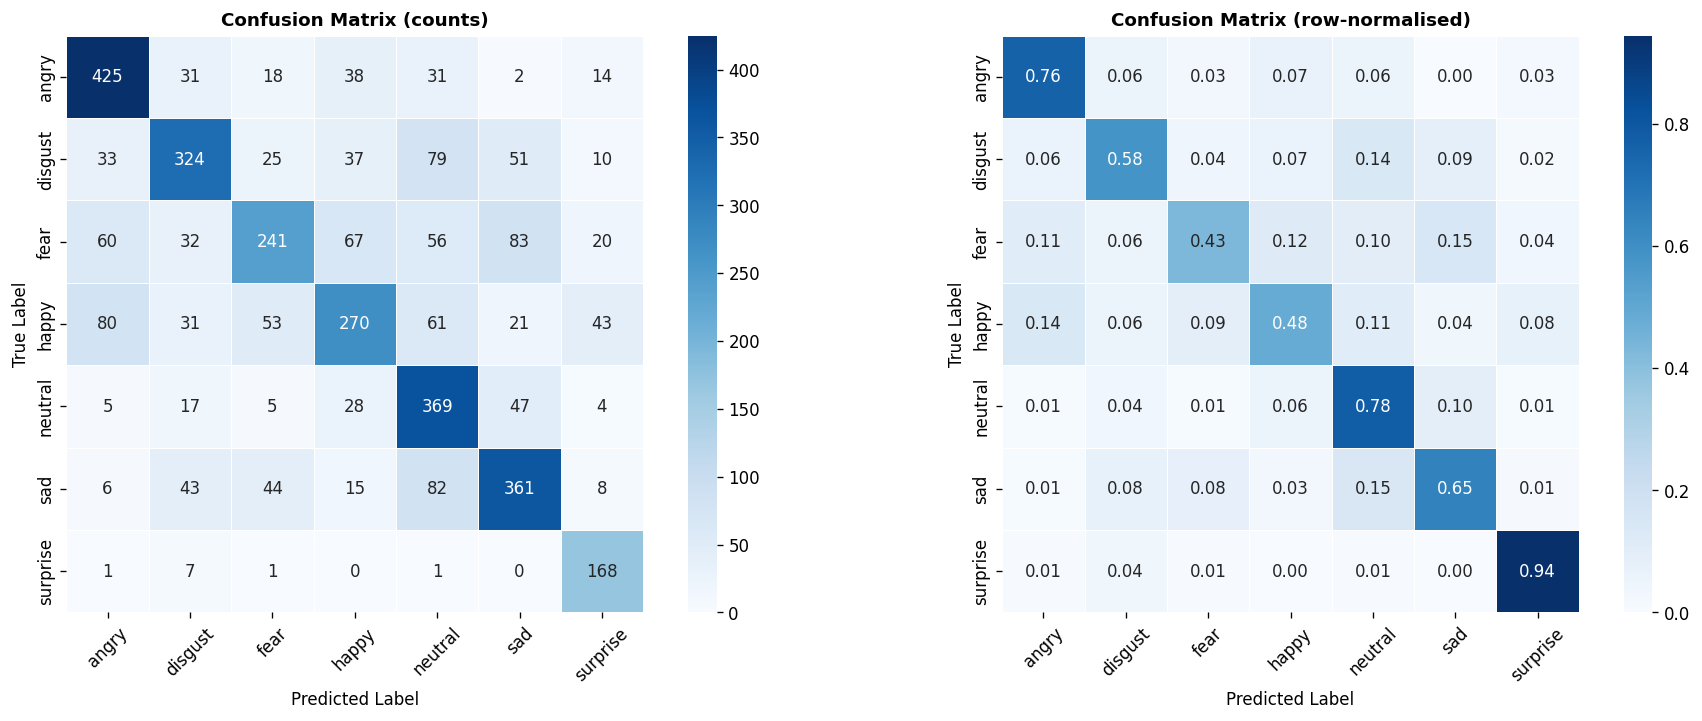

In [21]:
# ── Confusion matrix ───────────────────────────────────────────────────────────
cm = confusion_matrix(yw_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ["d", ".2f"],
    ["Confusion Matrix (counts)", "Confusion Matrix (row-normalised)"],
):
    sns.heatmap(
        data,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        ax=ax,
        linewidths=0.4,
        square=True,
    )
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [22]:
# ── Classification report ──────────────────────────────────────────────────────
report_str = classification_report(
    yw_test,
    y_pred,
    target_names=label_encoder.classes_,
    digits=4,
)
print("Classification Report — Test Set")
print("=" * 60)
print(report_str)

Classification Report — Test Set
              precision    recall  f1-score   support

       angry     0.6967    0.7603    0.7271       559
     disgust     0.6680    0.5796    0.6207       559
        fear     0.6227    0.4311    0.5095       559
       happy     0.5934    0.4830    0.5325       559
     neutral     0.5434    0.7768    0.6395       475
         sad     0.6389    0.6458    0.6423       559
    surprise     0.6292    0.9438    0.7551       178

    accuracy                         0.6259      3448
   macro avg     0.6275    0.6601    0.6324      3448
weighted avg     0.6294    0.6259    0.6187      3448



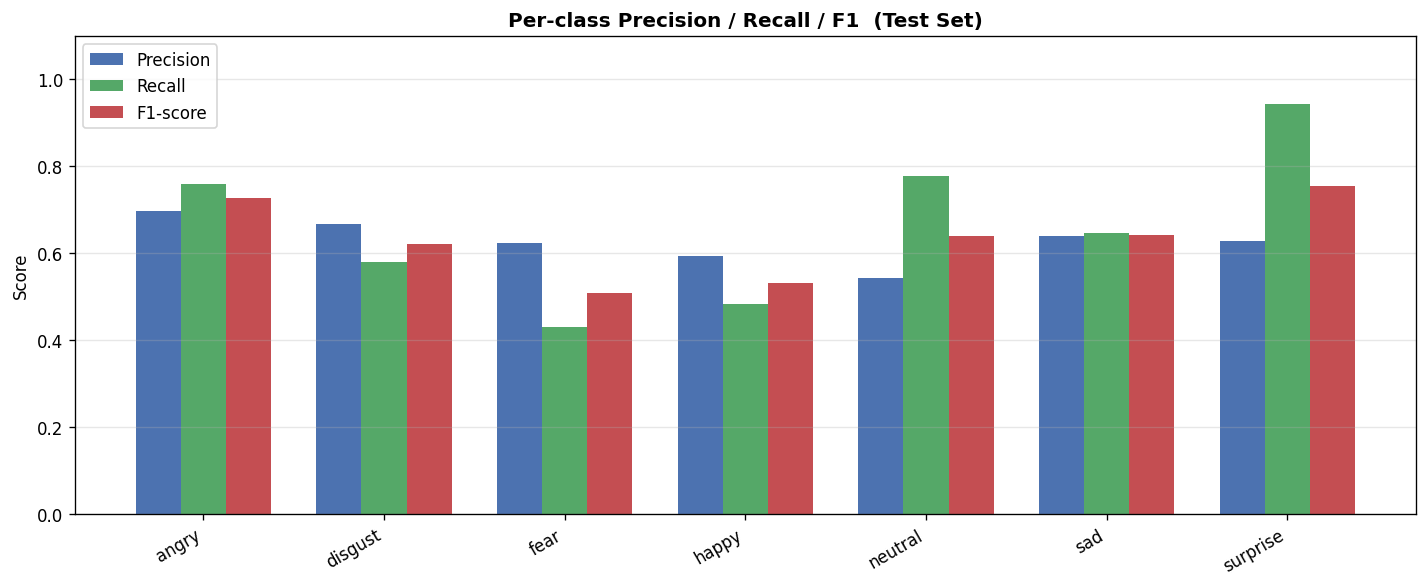


Per-class summary:
 Emotion  Precision  Recall  F1-score
   angry     0.6967  0.7603    0.7271
 disgust     0.6680  0.5796    0.6207
    fear     0.6227  0.4311    0.5095
   happy     0.5934  0.4830    0.5325
 neutral     0.5434  0.7768    0.6395
     sad     0.6389  0.6458    0.6423
surprise     0.6292  0.9438    0.7551


In [23]:
# ── Per-class metrics bar chart ────────────────────────────────────────────────
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    yw_test, y_pred, average=None, labels=np.arange(NUM_CLASSES)
)

x     = np.arange(NUM_CLASSES)
width = 0.25
class_names = label_encoder.classes_

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, precision, width, label="Precision", color="#4C72B0")
ax.bar(x,         recall,    width, label="Recall",    color="#55A868")
ax.bar(x + width, f1,        width, label="F1-score",  color="#C44E52")

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha="right")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Per-class Precision / Recall / F1  (Test Set)", fontweight="bold", fontsize=12)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPer-class summary:")
metrics_df = pd.DataFrame({
    "Emotion":   class_names,
    "Precision": precision.round(4),
    "Recall":    recall.round(4),
    "F1-score":  f1.round(4),
})
print(metrics_df.to_string(index=False))

## 14. Model Loading & Inference Demo

Demonstrates loading the saved model and running a single-file inference,
producing the softmax probability dictionary required by the MEDDS fusion layer.

In [24]:
# ── Reload saved model & encoder ──────────────────────────────────────────────
loaded_model = keras.models.load_model(
    str(MODEL_PATH),
    custom_objects={"YAMNetEmbeddingLayer": YAMNetEmbeddingLayer},
)
with open(ENCODER_PATH, "rb") as fh:
    loaded_encoder = pickle.load(fh)

print("Model and encoder reloaded successfully.")

Model and encoder reloaded successfully.


In [25]:
def predict_emotion(
    file_path: str,
    model: Model,
    encoder: LabelEncoder,
) -> dict[str, float]:
    """Run the full inference pipeline on a single audio file.

    Args:
        file_path : path to a .wav file
        model     : loaded Keras VoiceEmotionModel_v3
        encoder   : fitted LabelEncoder (classes in canonical order)

    Returns:
        dict mapping emotion name → probability (float in [0, 1]), sum == 1.0
    """
    waveform = preprocess_audio(file_path)          # (CLIP_SAMPLES,)
    waveform = waveform[np.newaxis, :]              # (1, CLIP_SAMPLES)
    probs    = model.predict(waveform, verbose=0)   # (1, 7)
    probs    = probs[0]                             # (7,)

    return {
        cls: float(f"{p:.6f}")
        for cls, p in zip(encoder.classes_, probs)
    }


# Demo inference on a random test file
demo_path        = df_test.sample(1, random_state=SEED)["path"].values[0]
demo_true_label  = df_test[df_test["path"] == demo_path]["label"].values[0]
demo_result      = predict_emotion(demo_path, loaded_model, loaded_encoder)
predicted_label  = max(demo_result, key=demo_result.get)

print(f"Demo file       : {demo_path}")
print(f"True label      : {demo_true_label}")
print(f"Predicted label : {predicted_label}")
print(f"Probabilities   : (sum = {sum(demo_result.values()):.6f})")
for emotion, prob in sorted(demo_result.items(), key=lambda x: -x[1]):
    bar = "█" * int(prob * 40)
    print(f"  {emotion:<10} {prob:.4f}  {bar}")

ValueError: Input 0 with name 'yamnet_embedding' of layer 'VoiceEmotionHead' is incompatible with the layer: expected shape=(None, 1024), found shape=(1, 48000)

In [ ]:
# ── Probability bar chart for the demo file ────────────────────────────────────
emotions = list(demo_result.keys())
probs    = list(demo_result.values())
colors   = ["#C44E52" if e == predicted_label else "#4C72B0" for e in emotions]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(emotions, probs, color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Probability")
ax.set_title(
    f"Emotion Probabilities — True: {demo_true_label}  |  Predicted: {predicted_label}",
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 15. Architecture Summary

```
┌─────────────────────────────────────────────────────────────────────┐
│                     VoiceEmotionModel_v3                            │
├─────────────────────────────────────────────────────────────────────┤
│  Input                                                              │
│    waveform          (batch, 48000)  float32                        │
│                                                                     │
│  YAMNetEmbeddingLayer  (trainable in fine-tuning phase)             │
│    ├─ Mel-spectrogram front-end   (internal to YAMNet)              │
│    ├─ MobileNet-style conv blocks (pretrained on AudioSet)          │
│    └─ Mean temporal pooling → (batch, 1024)                         │
│                                                                     │
│  Classification Head                                                │
│    Dense(512) + BatchNorm + ReLU + Dropout(0.4)                     │
│    Dense(256) + BatchNorm + ReLU + Dropout(0.3)                     │
│    Dense(7,   activation='softmax')                                 │
│                                                                     │
│  Output                                                             │
│    emotion_output    (batch, 7)   float32  [sums to 1.0]            │
│    [angry, disgust, fear, happy, neutral, sad, surprise]            │
└─────────────────────────────────────────────────────────────────────┘

Training strategy
  Phase 1 — Backbone frozen,  head trains on pre-extracted embeddings
             LR=1e-3, EarlyStopping(patience=5), ReduceLROnPlateau
  Phase 2 — Backbone partially unfrozen, end-to-end fine-tune
             LR=1e-4, EarlyStopping(patience=7), ReduceLROnPlateau

Saved artefacts
  Voice_Model/saved_models/voice_model_v3.keras
  Voice_Model/saved_models/label_encoder.pkl
```

In [ ]:
print("="*60)
print("MEDDS — Voice Emotion Model Training Complete")
print("="*60)
print(f"  Model saved  : {MODEL_PATH}")
print(f"  Encoder saved: {ENCODER_PATH}")
print(f"  Test accuracy: {test_accuracy*100:.2f} %")
print("\nEmotion output order:")
for i, cls in enumerate(loaded_encoder.classes_):
    print(f"  index {i}  →  {cls}")